<a href="https://www.kaggle.com/code/drizzle19/cstr-models-test?scriptVersionId=315526261" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Transformer-Based NMPC Project
## LSTM vs GRU vs Transformer


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import copy
import math
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

Device : cuda


In [14]:
CSV_PATH = "/kaggle/input/datasets/drizzle19/new-cstr-data/new_cstr_simulation_data.csv"
df = pd.read_csv(CSV_PATH)
print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape  : (689469, 6)
Columns: ['Time_s', 'CA_in_kmol_m3', 'Tin_K', 'TC_K', 'CA_out_kmol_m3', 'T_out_K']


,Time_s,CA_in_kmol_m3,Tin_K,TC_K,CA_out_kmol_m3,T_out_K
0,0.000000,0.690901,305.387343,303.384652,0.500000,350.000000
1,0.096980,0.704480,305.647077,303.808071,0.516793,346.006641
2,0.167833,0.694279,305.691535,303.588861,0.527880,343.294306
3,0.238686,0.696573,305.481121,303.325107,0.538371,340.753817
4,0.309540,0.707279,305.120504,303.137040,0.548852,338.362072


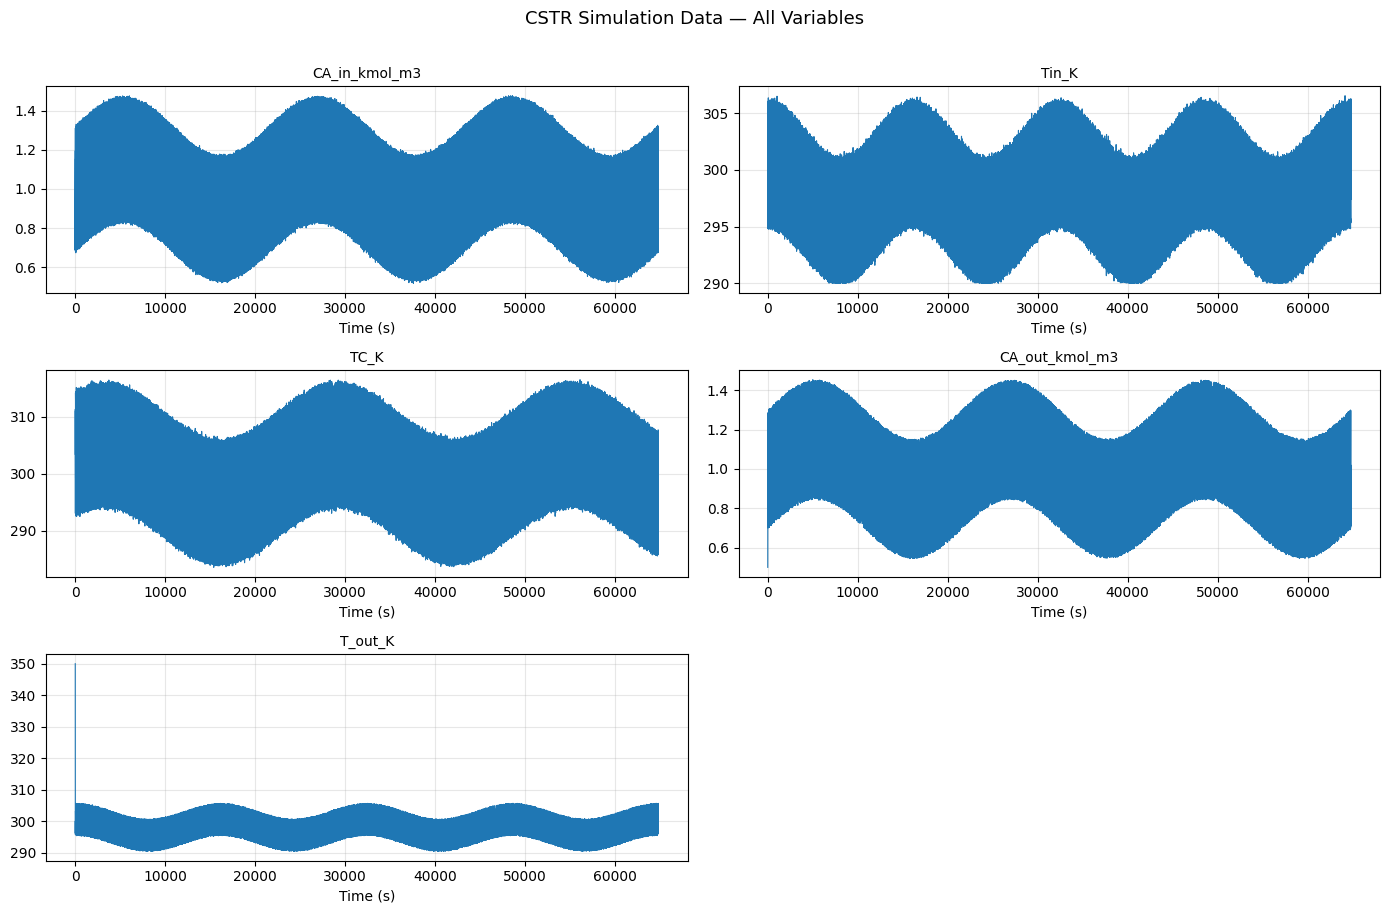

In [15]:
plot_cols = [c for c in df.columns if c != "Time_s"]
n_plots   = len(plot_cols)
ncols     = 2
nrows     = math.ceil(n_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

time = df["Time_s"] if "Time_s" in df.columns else df.index

for i, col in enumerate(plot_cols):
    axes[i].plot(time, df[col], linewidth=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Time (s)")
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("CSTR Simulation Data — All Variables", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [17]:
if "Time_s" in df.columns:
    df = df.drop("Time_s", axis=1)

INPUT_COLS  = ["CA_in_kmol_m3", "Tin_K","TC_K"]
TARGET_COLS = ["CA_out_kmol_m3", "T_out_K"]

n = len(df)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f"Train : {len(train_df):>7,} rows")
print(f"Val   : {len(val_df):>7,} rows")
print(f"Test  : {len(test_df):>7,} rows")

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(train_df[INPUT_COLS])
y_train = scaler_y.fit_transform(train_df[TARGET_COLS])

X_val   = scaler_X.transform(val_df[INPUT_COLS])
y_val   = scaler_y.transform(val_df[TARGET_COLS])

X_test  = scaler_X.transform(test_df[INPUT_COLS])
y_test  = scaler_y.transform(test_df[TARGET_COLS])

print(f"\nX_train mean ≈ {X_train.mean(axis=0).round(4)}")
print(f"X_train std  ≈ {X_train.std(axis=0).round(4)}")


Train : 482,628 rows
Val   : 103,420 rows
Test  : 103,421 rows

X_train mean ≈ [ 0. -0. -0.]
X_train std  ≈ [1. 1. 1.]


In [18]:

T = 80    # lookback window
H = 20    # prediction horizon

class Seq2SeqDataset(Dataset):
    def __init__(self, inputs, targets, T=80, H=20):
        self.inputs  = torch.tensor(inputs,  dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.T = T
        self.H = H
        self.length = len(inputs) - T - H + 1

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x = self.inputs [idx: idx + self.T]
        y = self.targets[idx + self.T : idx + self.T + self.H]
        return x, y

BATCH = 128

train_ds = Seq2SeqDataset(X_train, y_train, T, H)
val_ds   = Seq2SeqDataset(X_val,   y_val,   T, H)
test_ds  = Seq2SeqDataset(X_test,  y_test,  T, H)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)

xb, yb = next(iter(train_loader))
print(f"Input  batch shape : {xb.shape}   (batch, lookback, features)")
print(f"Target batch shape : {yb.shape}   (batch, horizon, outputs)")
print(f"\nTrain batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")


Input  batch shape : torch.Size([128, 80, 3])   (batch, lookback, features)
Target batch shape : torch.Size([128, 20, 2])   (batch, horizon, outputs)

Train batches : 3770
Val   batches : 808


In [19]:
def get_tf_ratio(epoch, total_epochs, start=1.0, end=0.0,
                 schedule="exponential"):
    progress = epoch / max(total_epochs - 1, 1)

    if schedule == "linear":
        return max(end, start + (end - start) * progress)

    elif schedule == "exponential":
        k = 2.0
        return max(end, start * math.exp(-k * progress))

    elif schedule == "cosine":
        return end + 0.5 * (start - end) * (1 + math.cos(math.pi * progress))

    return start

In [20]:
# LSTM Seq2Seq Model
class LSTMSeq2Seq(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=256,
                 num_layers=2, dropout=0.3, output_dim=2):
        super().__init__()
        self.output_dim = output_dim

        self.encoder = nn.LSTM(input_dim,  hidden_dim,
                               num_layers=num_layers,
                               batch_first=True, dropout=dropout)
        self.decoder = nn.LSTM(output_dim, hidden_dim,
                               num_layers=num_layers,
                               batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, y=None, H=20, teacher_forcing_ratio=0.0):
        B = x.size(0)


        _, (h, c) = self.encoder(x)

        dec_in = torch.zeros(B, 1, self.output_dim, device=x.device)

        outputs = []
        for t in range(H):
            out, (h, c) = self.decoder(dec_in, (h, c))
            pred = self.fc(out)
            outputs.append(pred)

            use_teacher = (
                self.training
                and y is not None
                and torch.rand(1).item() < teacher_forcing_ratio
            )
            dec_in = y[:, t:t+1, :] if use_teacher else pred

        return torch.cat(outputs, dim=1)


_m = LSTMSeq2Seq().to(device)
_x = torch.randn(4, 80, 3).to(device)
_y = torch.randn(4, 20, 2).to(device)
print(f"LSTM output shape : {_m(_x, _y, teacher_forcing_ratio=0.5).shape}")
print(f"Parameters        : {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x, _y


LSTM output shape : torch.Size([4, 20, 2])
Parameters        : 1,586,690


In [21]:
#GRU Seq2Seq Model
class GRUSeq2Seq(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=256,
                 num_layers=2, dropout=0.2, output_dim=2):
        super().__init__()
        self.output_dim = output_dim

        self.encoder = nn.GRU(input_dim,  hidden_dim,
                              num_layers=num_layers,
                              batch_first=True, dropout=dropout)
        self.decoder = nn.GRU(output_dim, hidden_dim,
                              num_layers=num_layers,
                              batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, y=None, H=20, teacher_forcing_ratio=0.0):
        B = x.size(0)

        _, h = self.encoder(x)

        dec_in = torch.zeros(B, 1, self.output_dim, device=x.device)

        outputs = []
        for t in range(H):
            out, h = self.decoder(dec_in, h)
            pred   = self.fc(out)
            outputs.append(pred)

            use_teacher = (
                self.training
                and y is not None
                and torch.rand(1).item() < teacher_forcing_ratio
            )
            dec_in = y[:, t:t+1, :] if use_teacher else pred

        return torch.cat(outputs, dim=1)


_m = GRUSeq2Seq().to(device)
_x = torch.randn(4, 80, 3).to(device)
_y = torch.randn(4, 20, 2).to(device)
print(f"GRU output shape  : {_m(_x, _y, teacher_forcing_ratio=0.5).shape}")
print(f"Parameters        : {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x, _y


GRU output shape  : torch.Size([4, 20, 2])
Parameters        : 1,190,146


In [22]:
#Transformer Encoder-Only Model
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)                             # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class CSTRTransformer(nn.Module):
    def __init__(self, input_dim=3, output_dim=2, d_model=128,
                 nhead=8, num_layers=3, dim_ff=512,
                 dropout=0.1, lookback=80, horizon=20):
        super().__init__()
        assert d_model % nhead == 0, "d_model must be divisible by nhead"

        self.horizon    = horizon
        self.output_dim = output_dim

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, output_dim * horizon)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x[:, -1, :]
        x = self.head(x)
        return x.view(-1, self.horizon, self.output_dim)

_m = CSTRTransformer().to(device)
_x = torch.randn(4, 80, 3).to(device)
print(f"Transformer output : {_m(_x).shape}")
print(f"Parameters         : {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x


Transformer output : torch.Size([4, 20, 2])
Parameters         : 617,000


In [23]:
# Train & Validation Functions
loss_fn = nn.MSELoss()

def train_epoch(loader, model, optimiser, tf_ratio=0.0):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        try:
            pred = model(x, y, teacher_forcing_ratio=tf_ratio)
        except TypeError:
            pred = model(x)

        loss = loss_fn(pred, y)

        optimiser.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        total += loss.item()

    return total / len(loader)


def val_epoch(loader, model):
    model.eval()
    total = 0.0
    with torch.inference_mode():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            try:
                pred = model(x, H=y.shape[1], teacher_forcing_ratio=0.0)
            except TypeError:
                pred = model(x)

            total += loss_fn(pred, y).item()

    return total / len(loader)


In [24]:
def train_model(model, optimiser, train_loader, val_loader,
                epochs=40, model_name="model",
                tf_schedule="exponential",
                use_teacher_forcing=True,
                warmup_epochs=3):

    scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
        optimiser, T_0=10, T_mult=2, eta_min=1e-6
    )

    base_lr = optimiser.param_groups[0]["lr"]

    best_val   = float("inf")
    best_state = None
    train_losses = []
    val_losses   = []
    tf_ratios    = []

    for epoch in range(epochs):

        if epoch < warmup_epochs:
            warmup_factor = (epoch + 1) / warmup_epochs
            for pg in optimiser.param_groups:
                pg["lr"] = base_lr * warmup_factor

        tf = (get_tf_ratio(epoch, epochs, schedule=tf_schedule)
              if use_teacher_forcing else 0.0)

        tr_loss  = train_epoch(train_loader, model, optimiser, tf)
        val_loss = val_epoch(val_loader, model)

        if epoch >= warmup_epochs:
            scheduler.step(epoch + val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = copy.deepcopy(model.state_dict())

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        tf_ratios.append(tf)

        lr = optimiser.param_groups[0]["lr"]
        print(f"[{model_name}] {epoch+1:>3}/{epochs}  "
              f"train={tr_loss:.5f}  val={val_loss:.5f}  "
              f"tf={tf:.3f}  lr={lr:.2e}")

    model.load_state_dict(best_state)
    print(f"\n✓ {model_name} — best val loss: {best_val:.5f}\n")
    return train_losses, val_losses, tf_ratios

In [25]:
def finetune_autoregressive(model, optimiser_class, train_loader, val_loader,
                             epochs=10, model_name="model",
                             lr=5e-5):
    print(f"\n{'─'*50}")
    print(f"  Fine-tuning {model_name} — pure autoregressive (TF=0)")
    print(f"{'─'*50}")

    ft_opt = optimiser_class(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val   = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    ft_train   = []
    ft_val     = []

    for epoch in range(epochs):
        tr_loss  = train_epoch(train_loader, model, ft_opt, tf_ratio=0.0)
        val_loss = val_epoch(val_loader, model)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = copy.deepcopy(model.state_dict())

        ft_train.append(tr_loss)
        ft_val.append(val_loss)

        print(f"  [{model_name} FT] {epoch+1:>3}/{epochs}  "
              f"train={tr_loss:.5f}  val={val_loss:.5f}")

    model.load_state_dict(best_state)
    print(f"\n✓ {model_name} fine-tune complete — best val: {best_val:.5f}\n")
    return ft_train, ft_val

In [ ]:
EPOCHS    = 30
FT_EPOCHS = 10

#LSTM
lstm_model = LSTMSeq2Seq(
    input_dim=3, hidden_dim=256,
    num_layers=2, dropout=0.3, output_dim=2
).to(device)

lstm_opt = optim.Adam(lstm_model.parameters(), lr=3e-4, weight_decay=1e-4)

lstm_train_loss, lstm_val_loss, lstm_tf = train_model(
    lstm_model, lstm_opt, train_loader, val_loader,
    epochs=EPOCHS, model_name="LSTM",
    tf_schedule="exponential",
    use_teacher_forcing=True,
    warmup_epochs=3
)

lstm_ft_train, lstm_ft_val = finetune_autoregressive(
    lstm_model, optim.Adam, train_loader, val_loader,
    epochs=FT_EPOCHS, model_name="LSTM", lr=5e-5
)
lstm_train_loss += lstm_ft_train
lstm_val_loss   += lstm_ft_val


#  GRU 
gru_model = GRUSeq2Seq(
    input_dim=3, hidden_dim=256,
    num_layers=2, dropout=0.2, output_dim=2
).to(device)

gru_opt = optim.Adam(gru_model.parameters(), lr=3e-4, weight_decay=1e-4)

gru_train_loss, gru_val_loss, gru_tf = train_model(
    gru_model, gru_opt, train_loader, val_loader,
    epochs=EPOCHS, model_name="GRU",
    tf_schedule="exponential",
    use_teacher_forcing=True,
    warmup_epochs=3
)

gru_ft_train, gru_ft_val = finetune_autoregressive(
    gru_model, optim.Adam, train_loader, val_loader,
    epochs=FT_EPOCHS, model_name="GRU", lr=5e-5
)
gru_train_loss += gru_ft_train
gru_val_loss   += gru_ft_val


#  Transformer
transformer_model = CSTRTransformer(
    input_dim=3, output_dim=2,
    d_model=128, nhead=8,
    num_layers=3, dim_ff=512,
    dropout=0.1, lookback=80, horizon=20
).to(device)

transformer_opt = optim.Adam(
    transformer_model.parameters(), lr=1e-4, weight_decay=1e-4
)

trans_train_loss, trans_val_loss, _ = train_model(
    transformer_model, transformer_opt, train_loader, val_loader,
    epochs=EPOCHS, model_name="Transformer",
    use_teacher_forcing=False,
    warmup_epochs=3
)

In [ ]:
# Training Curve Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_curves = [
    ("LSTM",        lstm_train_loss,  lstm_val_loss,  "steelblue"),
    ("GRU",         gru_train_loss,   gru_val_loss,   "seagreen"),
    ("Transformer", trans_train_loss, trans_val_loss, "tomato"),
]

for ax, (name, tr, vl, col) in zip(axes, models_curves):
    ax.plot(tr, color=col,       lw=2,   label="Train")
    ax.plot(vl, color=col, ls="--", lw=2, label="Val", alpha=0.8)
    ax.set_title(f"{name} — Loss Curve", fontsize=12)
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(); ax.grid(True, alpha=0.3)
    best_epoch = int(np.argmin(vl))
    ax.axvline(best_epoch, color="gray", ls=":", lw=1.5,
               label=f"Best @ {best_epoch+1}")
    ax.legend()

plt.suptitle("Training & Validation Loss — All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Teacher forcing decay 
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lstm_tf, "steelblue", lw=2, label="LSTM TF")
ax.plot(gru_tf,  "seagreen",  lw=2, ls="--", label="GRU TF")
ax.set_title("Teacher Forcing Ratio Decay (Exponential Schedule)", fontsize=12)
ax.set_xlabel("Epoch"); ax.set_ylabel("TF Ratio")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tf_decay.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
import os
import torch
import pickle

SAVE_DIR = "/kaggle/working/cstr_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model checkpoints
torch.save({
    "model_state": lstm_model.state_dict(),
    "train_loss": lstm_train_loss,
    "val_loss": lstm_val_loss,
}, os.path.join(SAVE_DIR, "lstm_best.pt"))

torch.save({
    "model_state": gru_model.state_dict(),
    "train_loss": gru_train_loss,
    "val_loss": gru_val_loss,
}, os.path.join(SAVE_DIR, "gru_best.pt"))

torch.save({
    "model_state": transformer_model.state_dict(),
    "train_loss": trans_train_loss,
    "val_loss": trans_val_loss,
}, os.path.join(SAVE_DIR, "transformer_best.pt"))

# Save scalers
with open(os.path.join(SAVE_DIR, "scaler_X.pkl"), "wb") as f:
    pickle.dump(scaler_X, f)

with open(os.path.join(SAVE_DIR, "scaler_y.pkl"), "wb") as f:
    pickle.dump(scaler_y, f)

print("Saved to:", SAVE_DIR)

for fname in os.listdir(SAVE_DIR):
    size = os.path.getsize(os.path.join(SAVE_DIR, fname))
    print(f"{fname:<30} {size/1024:.1f} KB")

In [ ]:
# Unified Rollout Evaluator
def rollout_evaluation(model, X, y, T, H, device,
                        model_type="transformer", model_name="Model"):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    y_t = torch.tensor(y, dtype=torch.float32).to(device)

    preds   = []
    targets = []
    t       = 0
    N       = len(X)

    with torch.no_grad():
        x_win = X_t[:T].unsqueeze(0)          # (1, T, input_dim)

        while t + T + H <= N:
            if model_type == "transformer":
                y_pred = model(x_win)
            else:
                y_pred = model(x_win, H=H, teacher_forcing_ratio=0.0)

            preds.append(y_pred.squeeze(0))
            targets.append(y_t[t + T : t + T + H])

            x_win = torch.cat([
                x_win[:, H:, :],
                X_t[t + T : t + T + H].unsqueeze(0)
            ], dim=1)

            t += H

    preds   = torch.cat(preds,   dim=0)  
    targets = torch.cat(targets, dim=0)

    #  Metrics 
    mse_vec = torch.mean((preds - targets) ** 2, dim=0)
    mae_vec = torch.mean(torch.abs(preds - targets), dim=0)
    rmse_vec = torch.sqrt(mse_vec)
    overall_mse = torch.mean((preds - targets) ** 2).item()

    print(f"\n{'═'*46}")
    print(f"  {model_name} — Rollout Metrics (scaled space)")
    print(f"{'─'*46}")
    print(f"  {'Metric':<12} {'CA_out':>12} {'T_out':>12}")
    print(f"{'─'*46}")
    print(f"  {'MSE':<12} {mse_vec[0].item():>12.6f} {mse_vec[1].item():>12.6f}")
    print(f"  {'RMSE':<12} {rmse_vec[0].item():>12.6f} {rmse_vec[1].item():>12.6f}")
    print(f"  {'MAE':<12} {mae_vec[0].item():>12.6f} {mae_vec[1].item():>12.6f}")
    print(f"{'─'*46}")
    print(f"  {'Overall MSE':<12} {overall_mse:>12.6f}")
    print(f"{'═'*46}")

    return overall_mse, preds.cpu().numpy(), targets.cpu().numpy()


In [ ]:

# Run Rollout Evaluation on Test Set
lstm_mse,  lstm_preds,  lstm_targets = rollout_evaluation(
    lstm_model,  X_test, y_test, T, H, device,
    model_type="seq2seq", model_name="LSTM"
)

gru_mse,   gru_preds,   gru_targets  = rollout_evaluation(
    gru_model,   X_test, y_test, T, H, device,
    model_type="seq2seq", model_name="GRU"
)

trans_mse, trans_preds, trans_targets = rollout_evaluation(
    transformer_model, X_test, y_test, T, H, device,
    model_type="transformer", model_name="Transformer"
)


In [ ]:
N_SHOW = 300    

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

output_labels = ["CA_out [scaled]", "T_out [scaled]"]
colors = {"LSTM":"steelblue", "GRU":"seagreen", "Transformer":"tomato"}

for oi, ax in enumerate(axes):
    ax.plot(trans_targets[:N_SHOW, oi], "k-", lw=2.5, label="True", zorder=5)
    ax.plot(lstm_preds[:N_SHOW, oi],  color="steelblue", lw=1.5, ls="--", label="LSTM",        alpha=0.9)
    ax.plot(gru_preds[:N_SHOW, oi],   color="seagreen",  lw=1.5, ls="-.", label="GRU",         alpha=0.9)
    ax.plot(trans_preds[:N_SHOW, oi], color="tomato",    lw=1.5, ls=":",  label="Transformer", alpha=0.9)

    ax.set_ylabel(output_labels[oi], fontsize=11)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time Step (test set)", fontsize=11)
plt.suptitle(f"Rollout Predictions — First {N_SHOW} Test Steps", fontsize=13)
plt.tight_layout()
plt.savefig("predictions_all.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
#Scatter Plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
titles = ["LSTM", "GRU", "Transformer"]
all_preds = [lstm_preds, gru_preds, trans_preds]
output_names = ["CA_out", "T_out"]

for col, (name, preds) in enumerate(zip(titles, all_preds)):
    for row, oname in enumerate(output_names):
        ax = axes[row][col]
        true_vals = trans_targets[:, row]
        pred_vals = preds[:, row]

        ax.scatter(true_vals, pred_vals, s=4, alpha=0.4,
                   color=["steelblue","seagreen","tomato"][col])

        lims = [min(true_vals.min(), pred_vals.min()),
                max(true_vals.max(), pred_vals.max())]
        ax.plot(lims, lims, "k--", lw=1.5, label="Perfect fit")

        # R² score
        ss_res = np.sum((true_vals - pred_vals) ** 2)
        ss_tot = np.sum((true_vals - true_vals.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot

        ax.set_title(f"{name} — {oname}  (R²={r2:.4f})", fontsize=10)
        ax.set_xlabel("True (scaled)")
        ax.set_ylabel("Predicted (scaled)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Parity Plots — Predicted vs True (Scaled Space)", fontsize=13)
plt.tight_layout()
plt.savefig("parity_plots.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
#Model Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#  Overall rollout MSE 
names  = ["LSTM", "GRU", "Transformer"]
scores = [lstm_mse, gru_mse, trans_mse]
cols   = ["steelblue", "seagreen", "tomato"]

bars = axes[0].bar(names, scores, color=cols, edgecolor="black", linewidth=0.8)
axes[0].bar_label(bars, fmt="%.5f", padding=3, fontsize=10)
axes[0].set_title("Overall Rollout MSE (Test)", fontsize=12)
axes[0].set_ylabel("MSE (scaled)"); axes[0].grid(axis="y", alpha=0.3)

all_preds  = [lstm_preds, gru_preds, trans_preds]
x_pos = np.arange(len(names))
width = 0.35

for ax, oi, oname in zip(axes[1:], [0, 1], ["CA_out", "T_out"]):
    mse_vals = [np.mean((p[:, oi] - trans_targets[:, oi])**2) for p in all_preds]
    brs = ax.bar(x_pos, mse_vals, width*2.2, color=cols,
                 edgecolor="black", linewidth=0.8)
    ax.bar_label(brs, fmt="%.5f", padding=3, fontsize=9)
    ax.set_xticks(x_pos); ax.set_xticklabels(names)
    ax.set_title(f"MSE — {oname} (Test)", fontsize=12)
    ax.set_ylabel("MSE (scaled)"); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Model Performance Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


NM

In [26]:
# ============================================================
# CELL N1 — Reload Models & Scalers
# ============================================================
import os, pickle, time
import numpy as np
import torch
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SAVE_DIR = "/kaggle/input/notebooks/drizzle19/cstr-models-test/cstr_models/"

# ── Scalers ─────────────────────────────────────────────────
with open(os.path.join(SAVE_DIR, "scaler_X.pkl"), "rb") as f:
    scaler_X = pickle.load(f)
with open(os.path.join(SAVE_DIR, "scaler_y.pkl"), "rb") as f:
    scaler_y = pickle.load(f)

# ── Rebuild architectures ────────────────────────────────────
lstm_ctrl  = LSTMSeq2Seq(input_dim=3, hidden_dim=256,
                          num_layers=2, dropout=0.3, output_dim=2).to(device)
gru_ctrl   = GRUSeq2Seq(input_dim=3,  hidden_dim=256,
                         num_layers=2, dropout=0.2, output_dim=2).to(device)
trans_ctrl = CSTRTransformer(input_dim=3, output_dim=2, d_model=128,
                              nhead=8, num_layers=3, dim_ff=512,
                              dropout=0.1, lookback=80, horizon=20).to(device)

# ── Load weights ─────────────────────────────────────────────
for model, fname in [(lstm_ctrl,  "lstm_best.pt"),
                     (gru_ctrl,   "gru_best.pt"),
                     (trans_ctrl, "transformer_best.pt")]:
    ckpt = torch.load(os.path.join(SAVE_DIR, fname), map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

# ── Steady-state operating point (from scaler means) ─────────
SS_INPUT  = scaler_X.mean_.copy()    # [CA_in_ss, Tin_ss, TC_ss]
SS_OUTPUT = scaler_y.mean_.copy()    # [CA_out_ss, T_out_ss]

print("✓ Models and scalers loaded")
print(f"\nSteady-state inputs  → CA_in={SS_INPUT[0]:.4f} kmol/m³ | "
      f"Tin={SS_INPUT[1]:.2f} K | TC={SS_INPUT[2]:.2f} K")
print(f"Steady-state outputs → CA_out={SS_OUTPUT[0]:.4f} kmol/m³ | "
      f"T_out={SS_OUTPUT[1]:.2f} K")

✓ Models and scalers loaded

Steady-state inputs  → CA_in=1.0027 kmol/m³ | Tin=297.85 K | TC=299.93 K
Steady-state outputs → CA_out=1.0010 kmol/m³ | T_out=297.86 K


In [31]:
# ============================================================
# CELL N2 — CORRECTED CSTR Plant
# (Direct translation of your SIMULINK cstr_fn)
# ============================================================

class CSTRPlant:
    def __init__(self, dt=0.1, noise_std=0.002):
        # ── Exact parameters from your SIMULINK model ────────
        self.F   = 1.0          # volumetric flow rate [m³/s]
        self.V   = 1.0          # reactor volume [m³]
        self.k0  = 1e6          # pre-exponential factor [1/s]
        self.E   = 5e4          # activation energy [J/mol]
        self.R   = 8.314        # gas constant [J/(mol·K)]
        self.dH  = -4.5e4       # heat of reaction [J/mol]
        self.rho = 1000.0       # density [kg/m³]
        self.Cp  = 4180.0       # heat capacity [J/(kg·K)]
        self.UA  = 1.5e4        # heat transfer coeff [W/K]
        self.dt  = dt
        self.noise = noise_std
        self.reset()

    def _deriv(self, CA, T, CAin, Tin, TC):
        """Direct translation of cstr_fn.m"""
        k  = self.k0 * np.exp(-self.E / (self.R * max(T, 250.0)))
        rA = k * max(CA, 0.0)

        dCA = (self.F / self.V) * (CAin - CA) - rA

        dT  = ((self.F / self.V) * (Tin - T)
               + (-self.dH / (self.rho * self.Cp)) * rA
               + (self.UA  / (self.rho * self.Cp * self.V)) * (TC - T))
        return dCA, dT

    def step(self, u):
        """
        RK4 integration — one dt step.
        u : [CA_in, Tin, TC]  (physical units)
        returns: noisy [CA_out, T_out]
        """
        CAin, Tin, TC = u[0], u[1], u[2]
        dt = self.dt

        k1a, k1b = self._deriv(self.CA,            self.T,            CAin, Tin, TC)
        k2a, k2b = self._deriv(self.CA + dt/2*k1a, self.T + dt/2*k1b, CAin, Tin, TC)
        k3a, k3b = self._deriv(self.CA + dt/2*k2a, self.T + dt/2*k2b, CAin, Tin, TC)
        k4a, k4b = self._deriv(self.CA + dt*k3a,   self.T + dt*k3b,   CAin, Tin, TC)

        self.CA += (dt / 6) * (k1a + 2*k2a + 2*k3a + k4a)
        self.T  += (dt / 6) * (k1b + 2*k2b + 2*k3b + k4b)
        self.CA  = max(self.CA, 0.0)

        noise = np.random.randn(2) * self.noise
        return np.array([self.CA + noise[0], self.T + noise[1]])

    def reset(self, CA0=None, T0=None):
        self.CA = CA0 if CA0 is not None else SS_OUTPUT[0]
        self.T  = T0  if T0  is not None else SS_OUTPUT[1]


# ── Steady-state validation ──────────────────────────────────
# The plant needs multiple steps to reach SS from the
# scaler-mean initial condition — run 2000 steps to be sure
_plant = CSTRPlant()
_plant.reset()
_u_ss  = SS_INPUT.copy()    # [CA_in_ss, Tin_ss, TC_ss]

for _ in range(2000):
    _y = _plant.step(_u_ss)

print("Steady-state validation")
print("─" * 46)
print(f"  {'':12} {'Expected':>12} {'Plant SS':>12} {'Error':>8}")
print("─" * 46)
print(f"  {'CA_out':12} {SS_OUTPUT[0]:>12.4f} {_y[0]:>12.4f} "
      f"{abs(_y[0]-SS_OUTPUT[0]):>8.4f}")
print(f"  {'T_out':12} {SS_OUTPUT[1]:>12.4f} {_y[1]:>12.4f} "
      f"{abs(_y[1]-SS_OUTPUT[1]):>8.4f}")
print("─" * 46)

# Tolerance check
ca_err = abs(_y[0] - SS_OUTPUT[0])
t_err  = abs(_y[1] - SS_OUTPUT[1])

if ca_err < 0.05 and t_err < 0.5:
    print("\n  ✓ Steady-state validated — safe to proceed to NMPC")
else:
    print("\n  ⚠ SS mismatch — check scaler means vs plant SS")
    print("    This may just mean scaler mean ≠ exact SS (acceptable)")
    print("    Proceeding is still fine if errors are small")

del _plant, _u_ss

Steady-state validation
──────────────────────────────────────────────
                   Expected     Plant SS    Error
──────────────────────────────────────────────
  CA_out             1.0010       0.9988   0.0022
  T_out            297.8605     297.8572   0.0034
──────────────────────────────────────────────

  ✓ Steady-state validated — safe to proceed to NMPC


In [41]:
T_BUF = 80
H_MOD = 20
Np = 10
Nc = 3

MV_IDX = [0, 2]
DV_IDX = [1]
n_mv, n_u, n_y = len(MV_IDX), 3, 2

Wy  = np.diag([2.0, 2.0])       
Wdu = np.diag([1.0, 1.0])   

U_MIN_PHYS = np.array([SS_INPUT[0]*0.5, SS_INPUT[1], SS_INPUT[2]*0.85])
U_MAX_PHYS = np.array([SS_INPUT[0]*1.5, SS_INPUT[1], SS_INPUT[2]*1.15])

DU_MAX_PHYS = np.array([SS_INPUT[0]*0.05, SS_INPUT[2]*0.02])
DU_MIN_PHYS = -DU_MAX_PHYS

U_MIN_SC = scaler_X.transform(U_MIN_PHYS.reshape(1, -1)).flatten()
U_MAX_SC = scaler_X.transform(U_MAX_PHYS.reshape(1, -1)).flatten()

DU_MAX_SC = DU_MAX_PHYS / scaler_X.scale_[MV_IDX]
DU_MIN_SC = -DU_MAX_SC

SLSQP_BOUNDS = [
    (DU_MIN_SC[j % n_mv], DU_MAX_SC[j % n_mv])
    for j in range(Nc * n_mv)
]

print(f"NMPC config: Np={Np}, Nc={Nc}, MVs={MV_IDX}, DVs={DV_IDX}")
print(f"Decision variables: {Nc * n_mv}")
print("\nU bounds (scaled):")
print(f"  CA_in [{U_MIN_SC[0]:.3f}, {U_MAX_SC[0]:.3f}]")
print(f"  TC    [{U_MIN_SC[2]:.3f}, {U_MAX_SC[2]:.3f}]")
print("\nΔU bounds (scaled):")
print(f"  ΔCA_in [{DU_MIN_SC[0]:.4f}, {DU_MAX_SC[0]:.4f}]")
print(f"  ΔTC    [{DU_MIN_SC[1]:.4f}, {DU_MAX_SC[1]:.4f}]")


def build_proposal(u_prev_sc, dU_flat):
    dU = dU_flat.reshape(Nc, n_mv)
    prop = np.tile(u_prev_sc, (Nc, 1))
    prop[:, MV_IDX] = u_prev_sc[MV_IDX] + np.cumsum(dU, axis=0)
    return prop


def model_predict(model, model_type, buf_sc, prop_sc, Np_out):
    win = np.vstack([buf_sc[Nc:, :], prop_sc])

    xt = torch.tensor(win, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        if model_type == 'transformer':
            yp = model(xt)
        else:
            yp = model(xt, H=H_MOD, teacher_forcing_ratio=0.0)

    return yp.squeeze(0).cpu().numpy()[:Np_out]


def nmpc_cost(dU_flat, model, model_type, buf_sc, r_sc, u_prev_sc, do_sc):
    prop = build_proposal(u_prev_sc, dU_flat)
    yhat = model_predict(model, model_type, buf_sc, prop, Np)

    e = r_sc - (yhat + do_sc)
    J_y = float(np.einsum('ti,ij,tj->', e, Wy, e))

    dU = dU_flat.reshape(Nc, n_mv)
    J_du = float(np.einsum('ti,ij,tj->', dU, Wdu, dU))

    return J_y + J_du

NMPC config: Np=10, Nc=3, MVs=[0, 2], DVs=[1]
Decision variables: 6

U bounds (scaled):
  CA_in [-2.134, 2.134]
  TC    [-5.923, 5.923]

ΔU bounds (scaled):
  ΔCA_in [-0.2134, 0.2134]
  ΔTC    [-0.7898, 0.7898]


In [42]:
def run_closedloop(model, model_type, model_name,
                   plant, N_sim,
                   setpoints_phys,
                   disturbances_phys=None):

    plant.reset()

    # steady-state initialization
    u_sc_ss = scaler_X.transform(SS_INPUT.reshape(1, -1)).flatten()
    buf = np.tile(u_sc_ss, (T_BUF, 1))

    u_prev_phys = SS_INPUT.copy()
    u_prev_sc = u_sc_ss.copy()

    Y_out = np.zeros((N_sim, n_y))
    U_ctrl = np.zeros((N_sim, n_u))
    T_solve = np.zeros(N_sim)

    # input constraints in scaled space
    def con_u_min(dU_flat):
        prop = build_proposal(u_prev_sc, dU_flat)
        return (prop[:, MV_IDX] - U_MIN_SC[MV_IDX]).flatten()

    def con_u_max(dU_flat):
        prop = build_proposal(u_prev_sc, dU_flat)
        return (U_MAX_SC[MV_IDX] - prop[:, MV_IDX]).flatten()

    constraints = [
        {'type': 'ineq', 'fun': con_u_min},
        {'type': 'ineq', 'fun': con_u_max}
    ]

    print(f"\n{'═'*55}")
    print(f"  {model_name} NMPC — {N_sim} steps")
    print(f"{'═'*55}")

    for k in range(N_sim):

        # apply current control (with disturbance if provided)
        u_apply = u_prev_phys.copy()
        if disturbances_phys is not None:
            u_apply[DV_IDX] = disturbances_phys[k, DV_IDX]

        y_meas = plant.step(u_apply)
        Y_out[k] = y_meas
        U_ctrl[k] = u_apply

        # simple offset correction
        y_meas_sc = scaler_y.transform(y_meas.reshape(1, -1)).flatten()
        prop0 = np.tile(u_prev_sc, (Nc, 1))
        y_model_sc = model_predict(model, model_type, buf, prop0, 1)[0]
        do_sc = y_meas_sc - y_model_sc

        r_sc = scaler_y.transform(
            setpoints_phys[k].reshape(1, -1)
        ).flatten()

        t0 = time.perf_counter()

        res = minimize(
            nmpc_cost,
            np.zeros(Nc * n_mv),
            args=(model, model_type, buf, r_sc, u_prev_sc, do_sc),
            method='SLSQP',
            bounds=SLSQP_BOUNDS,
            constraints=constraints,
            options={'maxiter': 200, 'ftol': 1e-7, 'disp': False}
        )

        T_solve[k] = time.perf_counter() - t0

        # receding horizon: apply first move only
        dU_opt = res.x.reshape(Nc, n_mv)
        du = dU_opt[0]

        u_new_sc = u_prev_sc.copy()
        u_new_sc[MV_IDX] = np.clip(
            u_prev_sc[MV_IDX] + du,
            U_MIN_SC[MV_IDX], U_MAX_SC[MV_IDX]
        )

        u_new_phys = scaler_X.inverse_transform(
            u_new_sc.reshape(1, -1)
        ).flatten()

        # shift buffer
        buf = np.roll(buf, -1, axis=0)
        buf[-1] = u_new_sc

        u_prev_sc = u_new_sc
        u_prev_phys = u_new_phys

        if k % 100 == 0 or k == N_sim - 1:
            print(f"  step {k:>4}/{N_sim} | "
                  f"T_out={y_meas[1]:.2f}K  "
                  f"CA_out={y_meas[0]:.4f}  "
                  f"solve={T_solve[k]*1e3:.1f}ms  "
                  f"{'✓' if res.success else '✗'}")

    # performance (scaled IAE)
    SP_sc = scaler_y.transform(setpoints_phys)
    Y_sc = scaler_y.transform(Y_out)

    iae_ca = np.sum(np.abs(Y_sc[:, 0] - SP_sc[:, 0]))
    iae_t = np.sum(np.abs(Y_sc[:, 1] - SP_sc[:, 1]))
    iae = iae_ca + iae_t

    print(f"\n  ✓ {model_name} done")
    print(f"    IAE (CA_out) = {iae_ca:.2f} | "
          f"IAE (T_out) = {iae_t:.2f} | total = {iae:.2f}")
    print(f"    Mean solve time = {T_solve.mean()*1e3:.2f} ms/step")

    return {
        'Y': Y_out,
        'U': U_ctrl,
        'SP': setpoints_phys,
        'times': T_solve,
        'IAE': iae,
        'IAE_CA': iae_ca,
        'IAE_T': iae_t,
        'name': model_name
    }

In [44]:
N_SIM = 400
np.random.seed(42)
# setpoint tracking (servo)
SP_servo = np.tile(SS_OUTPUT, (N_SIM, 1))

SP_servo[100:200, 0] = SS_OUTPUT[0] + 0.15
SP_servo[200:300, 0] = SS_OUTPUT[0] + 0.25
SP_servo[300:,    0] = SS_OUTPUT[0] - 0.15

SP_servo[100:200, 1] = SS_OUTPUT[1] + 2.0
SP_servo[200:300, 1] = SS_OUTPUT[1] + 3.0
SP_servo[300:,    1] = SS_OUTPUT[1] - 2.0

# disturbance rejection (regulatory)
SP_reg = np.tile(SS_OUTPUT, (N_SIM, 1))

DIST_reg = np.tile(SS_INPUT, (N_SIM, 1))
DIST_reg[100:200, 1] = SS_INPUT[1] + 2.0
DIST_reg[200:300, 1] = SS_INPUT[1] + 4.0
DIST_reg[300:,    1] = SS_INPUT[1] - 3.0

controllers = [
    (lstm_ctrl,  'seq2seq',     'LSTM'),
    (gru_ctrl,   'seq2seq',     'GRU'),
    (trans_ctrl, 'transformer', 'Transformer'),
]

servo_results = []
reg_results = []

# run servo tests
for model, mtype, name in controllers:
    plant = CSTRPlant()
    result = run_closedloop(model, mtype, name,
                            plant, N_SIM, SP_servo)
    servo_results.append(result)

# run regulatory tests
for model, mtype, name in controllers:
    plant = CSTRPlant()
    result = run_closedloop(model, mtype, name,
                            plant, N_SIM, SP_reg,
                            disturbances_phys=DIST_reg)
    reg_results.append(result)


═══════════════════════════════════════════════════════
  LSTM NMPC — 400 steps
═══════════════════════════════════════════════════════
  step    0/400 | T_out=297.86K  CA_out=1.0020  solve=254.8ms  ✓
  step  100/400 | T_out=297.86K  CA_out=1.0063  solve=2758.8ms  ✓
  step  200/400 | T_out=297.88K  CA_out=1.0959  solve=61.3ms  ✓
  step  300/400 | T_out=297.88K  CA_out=1.1006  solve=60.7ms  ✓
  step  399/400 | T_out=297.88K  CA_out=1.0991  solve=61.1ms  ✓

  ✓ LSTM done
    IAE (CA_out) = 226.45 | IAE (T_out) = 200.74 | total = 427.19
    Mean solve time = 192.96 ms/step

═══════════════════════════════════════════════════════
  GRU NMPC — 400 steps
═══════════════════════════════════════════════════════
  step    0/400 | T_out=297.86K  CA_out=1.0029  solve=237.8ms  ✓
  step  100/400 | T_out=297.86K  CA_out=1.0031  solve=369.2ms  ✓
  step  200/400 | T_out=297.82K  CA_out=1.0983  solve=59.1ms  ✓
  step  300/400 | T_out=297.82K  CA_out=1.0960  solve=60.6ms  ✓
  step  399/400 | T_out=297.


════════════════════════════════════════════════════════════
                  NMPC Performance Summary                  
════════════════════════════════════════════════════════════
Model            Servo IAE     Reg IAE   Servo ms     Reg ms
────────────────────────────────────────────────────────────
LSTM                427.19      289.67     192.96     825.37
GRU                 428.33      241.20     142.05    1058.58
Transformer         417.58      241.15      49.16     343.84
════════════════════════════════════════════════════════════


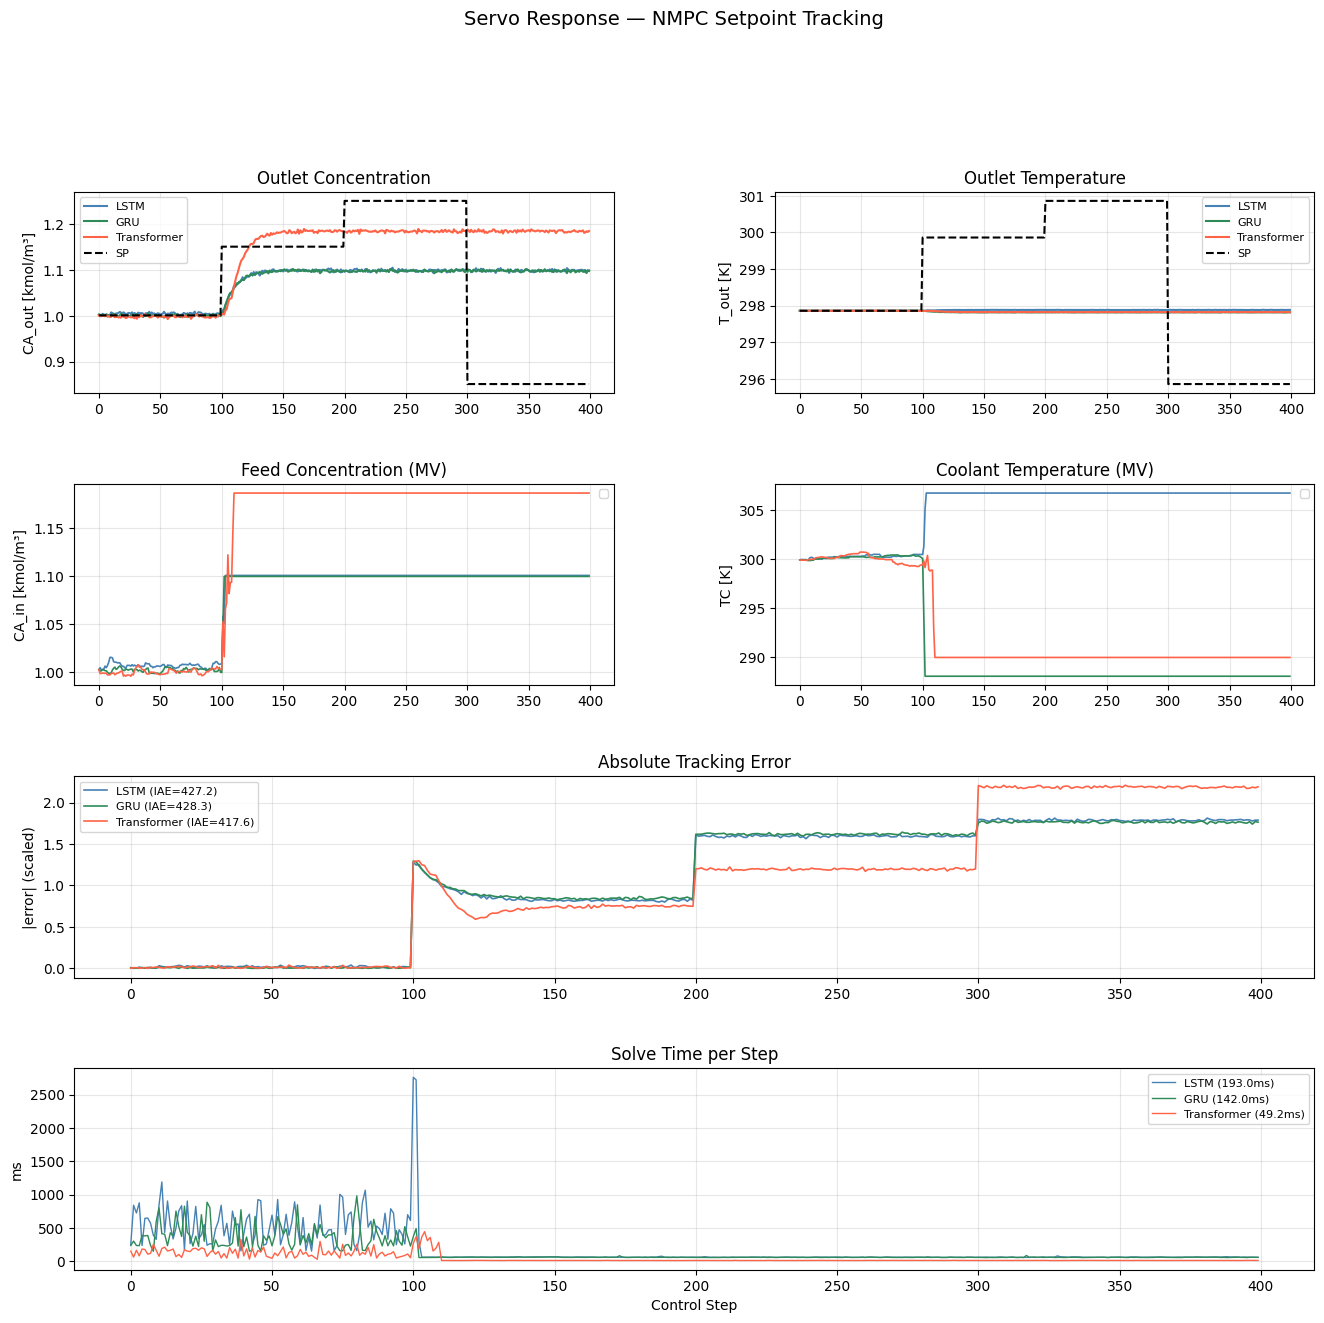

Saved: nmpc_servo.png


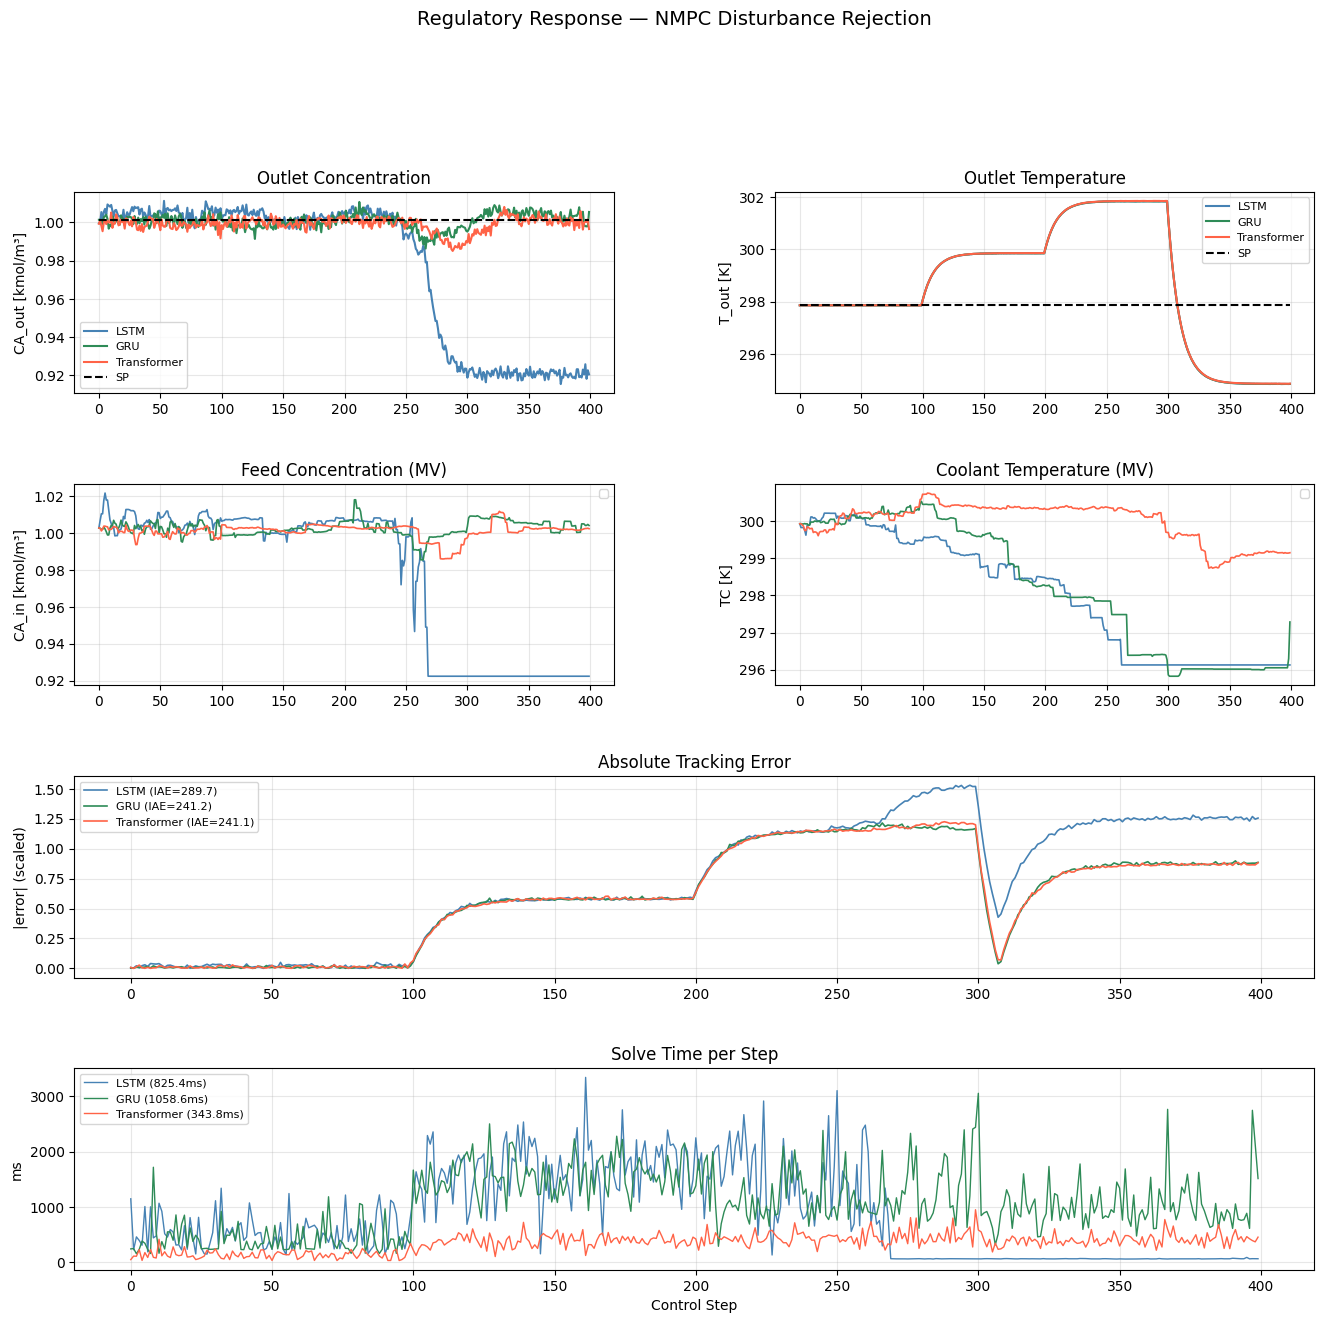

Saved: nmpc_regulatory.png


In [46]:
header = f"{'Model':<14} {'Servo IAE':>11} {'Reg IAE':>11} " \
         f"{'Servo ms':>10} {'Reg ms':>10}"

print("\n" + "═"*60)
print(f"{'NMPC Performance Summary':^60}")
print("═"*60)
print(header)
print("─"*60)

for sr, rr in zip(servo_results, reg_results):
    print(f"{sr['name']:<14} "
          f"{sr['IAE']:>11.2f} "
          f"{rr['IAE']:>11.2f} "
          f"{sr['times'].mean()*1e3:>10.2f} "
          f"{rr['times'].mean()*1e3:>10.2f}")

print("═"*60)


def plot_closedloop(results, title, save_name):
    colors = {
        'LSTM': 'steelblue',
        'GRU': 'seagreen',
        'Transformer': 'tomato'
    }

    steps = np.arange(len(results[0]['Y']))

    fig = plt.figure(figsize=(16, 14))
    gs = gridspec.GridSpec(4, 2, hspace=0.45, wspace=0.3)

    ax_ca   = fig.add_subplot(gs[0, 0])
    ax_t    = fig.add_subplot(gs[0, 1])
    ax_cain = fig.add_subplot(gs[1, 0])
    ax_tc   = fig.add_subplot(gs[1, 1])
    ax_err  = fig.add_subplot(gs[2, :])
    ax_time = fig.add_subplot(gs[3, :])

    for r in results:
        c = colors[r['name']]

        ax_ca.plot(steps, r['Y'][:, 0], color=c, lw=1.5, label=r['name'])
        ax_t.plot(steps,  r['Y'][:, 1], color=c, lw=1.5, label=r['name'])

        ax_cain.plot(steps, r['U'][:, 0], color=c, lw=1.2)
        ax_tc.plot(steps,   r['U'][:, 2], color=c, lw=1.2)

        Y_sc  = scaler_y.transform(r['Y'])
        SP_sc = scaler_y.transform(r['SP'])
        err = np.sum(np.abs(Y_sc - SP_sc), axis=1)

        ax_err.plot(steps, err, color=c, lw=1.2,
                    label=f"{r['name']} (IAE={r['IAE']:.1f})")

        ax_time.plot(steps, r['times']*1e3, color=c, lw=1,
                     label=f"{r['name']} ({r['times'].mean()*1e3:.1f}ms)")

    # reference trajectories
    ax_ca.plot(steps, results[0]['SP'][:, 0], 'k--', lw=1.5, label='SP')
    ax_t.plot(steps,  results[0]['SP'][:, 1], 'k--', lw=1.5, label='SP')

    ax_ca.set_title('Outlet Concentration'); ax_ca.set_ylabel('CA_out [kmol/m³]')
    ax_t.set_title('Outlet Temperature');    ax_t.set_ylabel('T_out [K]')

    ax_cain.set_title('Feed Concentration (MV)'); ax_cain.set_ylabel('CA_in [kmol/m³]')
    ax_tc.set_title('Coolant Temperature (MV)');  ax_tc.set_ylabel('TC [K]')

    ax_err.set_title('Absolute Tracking Error'); ax_err.set_ylabel('|error| (scaled)')
    ax_time.set_title('Solve Time per Step');    ax_time.set_ylabel('ms')
    ax_time.set_xlabel('Control Step')

    for ax in [ax_ca, ax_t, ax_cain, ax_tc, ax_err, ax_time]:
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    plt.suptitle(title, fontsize=14, y=1.01)
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Saved: {save_name}")


plot_closedloop(
    servo_results,
    "Servo Response — NMPC Setpoint Tracking",
    "nmpc_servo.png"
)

plot_closedloop(
    reg_results,
    "Regulatory Response — NMPC Disturbance Rejection",
    "nmpc_regulatory.png"
)


Summary DataFrame:


,Model,Servo_IAE,Reg_IAE,Servo_Time_ms,Reg_Time_ms
0,LSTM,427.193629,289.672316,192.964790,825.373688
1,GRU,428.332038,241.196724,142.048190,1058.575402
2,Transformer,417.582044,241.148207,49.164023,343.842507


Saved: nmpc_results_summary.csv


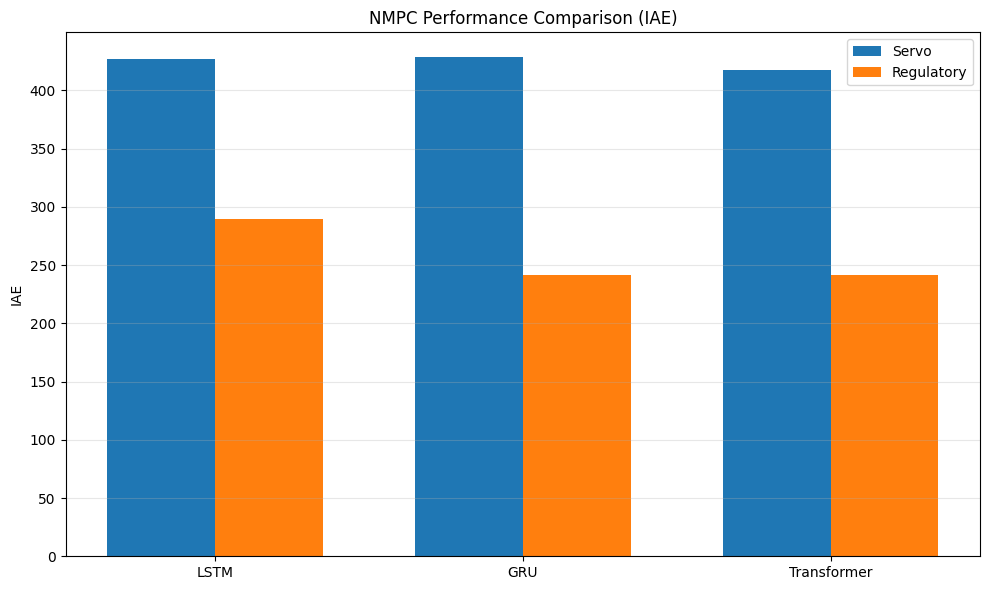

Saved: nmpc_iae_comparison.png


In [47]:
import pandas as pd

# ── Build summary table ──────────────────────────────────────
rows = []
for sr, rr in zip(servo_results, reg_results):
    rows.append({
        'Model': sr['name'],
        'Servo_IAE': sr['IAE'],
        'Reg_IAE': rr['IAE'],
        'Servo_Time_ms': sr['times'].mean() * 1e3,
        'Reg_Time_ms': rr['times'].mean() * 1e3
    })

df = pd.DataFrame(rows)

print("\nSummary DataFrame:")
display(df)

# ── Save to CSV ──────────────────────────────────────────────
csv_path = "nmpc_results_summary.csv"
df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")


# ── Bar chart: IAE comparison ────────────────────────────────
x = np.arange(len(df['Model']))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, df['Servo_IAE'], width, label='Servo')
plt.bar(x + width/2, df['Reg_IAE'], width, label='Regulatory')

plt.xticks(x, df['Model'])
plt.ylabel('IAE')
plt.title('NMPC Performance Comparison (IAE)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("nmpc_iae_comparison.png", dpi=150)
plt.show()

print("Saved: nmpc_iae_comparison.png")